In [2]:
# Installing the required libraries
!pip install yfinance

In [3]:
# Importing required Libraries
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.linear_model import LinearRegression 
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Importing/Downloading the dataset
usd_inr_raw = yf.download('INR=X', start='2025-01-01', end='2025-12-31', progress=False)
gold_raw = yf.download('GC=F', start='2025-01-01', end='2025-12-31', progress=False)

In [5]:
usd_inr_raw

Price,Close,High,Low,Open,Volume
Ticker,INR=X,INR=X,INR=X,INR=X,INR=X
Date,,,,,
2025-01-02,85.785698,86.033997,85.573997,85.785698,0
2025-01-03,85.804001,86.072304,85.706299,85.804001,0
2025-01-06,85.759003,85.841003,85.584297,85.759003,0
2025-01-07,85.680702,85.793800,84.939598,85.680702,0
2025-01-08,85.806503,85.985603,85.706001,85.806503,0
...,...,...,...,...,...
2025-12-23,89.603897,89.833000,89.430901,89.603996,0
2025-12-24,89.507896,89.865700,89.422997,89.507896,0


In [6]:
'''
Depending on the version of yfinance, downloading single tickers can return a DataFrame with a MultiIndex column 
(a nested header structure like ('Close', 'INR=X') instead of a plain 'Close'). When this happens, selecting ['Close'] still results 
in a 2D DataFrame with 1 column
'''

"\nDepending on the version of yfinance, downloading single tickers can return a DataFrame with a MultiIndex column \n(a nested header structure like ('Close', 'INR=X') instead of a plain 'Close'). When this happens, selecting ['Close'] still results \nin a 2D DataFrame with 1 column\n"

In [7]:
# Checking the dimensionality of a single feature/column
usd_inr_raw['Close']

Ticker,INR=X
Date,
2025-01-02,85.785698
2025-01-03,85.804001
2025-01-06,85.759003
2025-01-07,85.680702
2025-01-08,85.806503
...,...
2025-12-23,89.603897
2025-12-24,89.507896
2025-12-26,90.105904


In [8]:
usd_inr_raw['Close'].shape

(256, 1)

In [9]:
"""
WHY .squeeze() IS REQUIRED HERE:

1. The Problem (2D vs 1D Structure):
   - In modern versions of yfinance, downloading a ticker returns a 2D DataFrame with 
     a nested/MultiIndex column header.
   - Even after selecting ['Close'], the output is still a 2D DataFrame with shape (N, 1) 
     — meaning N rows and an axis of length 1 (a single column named 'INR=X' or 'GC=F').

2. What .squeeze() Does:
   - In Pandas, .squeeze() inspects the object's dimensions and strips away any axis whose 
     length equals 1.
   - It flattens the 2D single-column DataFrame (shape: (N, 1)) down into a native 1D 
     Pandas Series (shape: (N,)).

3. Why DataFrame Construction Needs This:
   - When merging these features into `pd.DataFrame({'USD_INR': usd_close, ...})`, Pandas 
     expects clean 1D Series as dictionary values.
   - If you pass un-squeezed 2D DataFrames, Pandas creates a messy 2-level MultiIndex 
     column hierarchy like ('USD_INR', 'INR=X').
   - Flattening to a 1D Series ensures the resulting DataFrame has clean, flat column names 
     ('USD_INR', 'Gold_USD_oz') and avoids downstream `KeyError` exceptions.
"""

"\nWHY .squeeze() IS REQUIRED HERE:\n\n1. The Problem (2D vs 1D Structure):\n   - In modern versions of yfinance, downloading a ticker returns a 2D DataFrame with \n     a nested/MultiIndex column header.\n   - Even after selecting ['Close'], the output is still a 2D DataFrame with shape (N, 1) \n     — meaning N rows and an axis of length 1 (a single column named 'INR=X' or 'GC=F').\n\n2. What .squeeze() Does:\n   - In Pandas, .squeeze() inspects the object's dimensions and strips away any axis whose \n     length equals 1.\n   - It flattens the 2D single-column DataFrame (shape: (N, 1)) down into a native 1D \n     Pandas Series (shape: (N,)).\n\n3. Why DataFrame Construction Needs This:\n   - When merging these features into `pd.DataFrame({'USD_INR': usd_close, ...})`, Pandas \n     expects clean 1D Series as dictionary values.\n   - If you pass un-squeezed 2D DataFrames, Pandas creates a messy 2-level MultiIndex \n     column hierarchy like ('USD_INR', 'INR=X').\n   - Flattening to

In [10]:
# Flattenning the columns 
usd_close = usd_inr_raw['Close'].squeeze()
gold_close = gold_raw['Close'].squeeze()

In [11]:
# Checking whether the changes took place
print(f'\t Flattenned Data: \n {usd_close}')
print(f' \n\t Flattenned Data: \n {gold_close}')

	 Flattenned Data: 
 Date
2025-01-02    85.785698
2025-01-03    85.804001
2025-01-06    85.759003
2025-01-07    85.680702
2025-01-08    85.806503
                ...    
2025-12-23    89.603897
2025-12-24    89.507896
2025-12-26    90.105904
2025-12-29    89.829300
2025-12-30    89.900002
Name: INR=X, Length: 256, dtype: float64
 
	 Flattenned Data: 
 Date
2025-01-02    2658.899902
2025-01-03    2645.000000
2025-01-06    2638.399902
2025-01-07    2656.699951
2025-01-08    2664.500000
                 ...     
2025-12-23    4482.799805
2025-12-24    4480.600098
2025-12-26    4529.100098
2025-12-29    4325.100098
2025-12-30    4370.100098
Name: GC=F, Length: 251, dtype: float64


In [12]:
# Movinig the above to DataFrame 
goldprice_df = pd.DataFrame({
    'USD_INR'    : usd_close,
    'Gold_UDS-oz' : gold_close
    
})

# Getting the first 5 rows of the DataFrame
goldprice_df.head()

,USD_INR,Gold_UDS-oz
Date,,
2025-01-02,85.785698,2658.899902
2025-01-03,85.804001,2645.000000
2025-01-06,85.759003,2638.399902
2025-01-07,85.680702,2656.699951
2025-01-08,85.806503,2664.500000


In [13]:
# Converting international Troy Ounce USD to domestic 22K INR per gram
TROY_OUNCE_TO_GRAM = 31.1034768                                            # 1 Troy Ounce = 31.1034768 grams
PURITY = 22 / 24                                                           # 22 Karat = 22/24 purity

goldprice_df['Gold_Price'] = (goldprice_df['Gold_UDS-oz'] /  TROY_OUNCE_TO_GRAM) * goldprice_df['USD_INR'] * PURITY

In [14]:
# Getting it in clean table structure
goldprice_df = goldprice_df[['USD_INR', 'Gold_Price']].round(2).reset_index()
goldprice_df.rename(columns = {'index' : 'Date'}, inplace = True)


# Getting the first 5 rows
goldprice_df.head()

,Date,USD_INR,Gold_Price
0,2025-01-02,85.79,6722.32
1,2025-01-03,85.80,6688.61
2,2025-01-06,85.76,6668.42
3,2025-01-07,85.68,6708.54
4,2025-01-08,85.81,6738.12


### EDA

- Missing Values                    -> Handled
- Imbalanced Dataset                -> No Imbalance
- Handled Outliers                  -> No Outliers
- Encoded Categorical Features      -> No Categorical Features
- Normalization Vs Standardisation  -> Standardisation

In [15]:
# Getting the shape of the DataFrame
goldprice_df.shape

(257, 3)

In [16]:
'''
Rows     -> 257
Columns  -> 3
'''

'\nRows     -> 257\nColumns  -> 3\n'

In [17]:
# Getting the datatypes of each columns in the DataFrame
goldprice_df.dtypes

Date          datetime64[s]
USD_INR             float64
Gold_Price          float64
dtype: object

In [18]:
'''
Datatypes:
-> Date column should be in Date format. 
-> The other columns are in the appropriate columns.

But here as the Date feature isn't necessary for modelling, we don't need to give importance to that and there is no need to change 
the datatype of it. 
'''

"\nDatatypes:\n-> Date column should be in Date format. \n-> The other columns are in the appropriate columns.\n\nBut here as the Date feature isn't necessary for modelling, we don't need to give importance to that and there is no need to change \nthe datatype of it. \n"

In [19]:
# Checking whether there are any NULL values
goldprice_df.isnull().sum().any().item()

True

In [20]:
'''
True -> Means that there are NULL values in the Dataset
'''

'\nTrue -> Means that there are NULL values in the Dataset\n'

In [21]:
# Checking the column-wise NULL values
goldprice_df.isnull().sum()

Date          0
USD_INR       1
Gold_Price    7
dtype: int64

In [22]:
'''
NULL value counts: 
Date        -> 0 NULL values
USD_INR     -> 1 NULL value
Gold_Price  -> 7 NULL values
'''

'\nNULL value counts: \nDate        -> 0 NULL values\nUSD_INR     -> 1 NULL value\nGold_Price  -> 7 NULL values\n'

In [23]:
'''
Check missing value rate: 8 missing rows out of 257 total
Industry standard allows dropping rows if missingness is below 5% (MCAR - Missing Completely At Random).
These gaps are simply unsynced market holidays between US (Gold) and India (Forex), 
so dropping them via df.dropna() will not bias the model.
'''

'\nCheck missing value rate: 8 missing rows out of 257 total\nIndustry standard allows dropping rows if missingness is below 5% (MCAR - Missing Completely At Random).\nThese gaps are simply unsynced market holidays between US (Gold) and India (Forex), \nso dropping them via df.dropna() will not bias the model.\n'

In [24]:
# Checking missing value rate:
((7 + 1) / 257) * 100

3.11284046692607

In [25]:
'''
This missing value rate is below 5% rule. Therefore we can safely drop the missing values.
'''

'\nThis missing value rate is below 5% rule. Therefore we can safely drop the missing values.\n'

In [26]:
# Dropping the missing values
goldprice_df.dropna(inplace = True)

# Checking whether the changes took place
goldprice_df.isnull().sum()

Date          0
USD_INR       0
Gold_Price    0
dtype: int64

In [27]:
# Checking whether there are duplicate values
goldprice_df.duplicated().sum().item()

0

In [28]:
'''
Explanation:
0 -> Means that there are no duplicate values
'''

'\nExplanation:\n0 -> Means that there are no duplicate values\n'

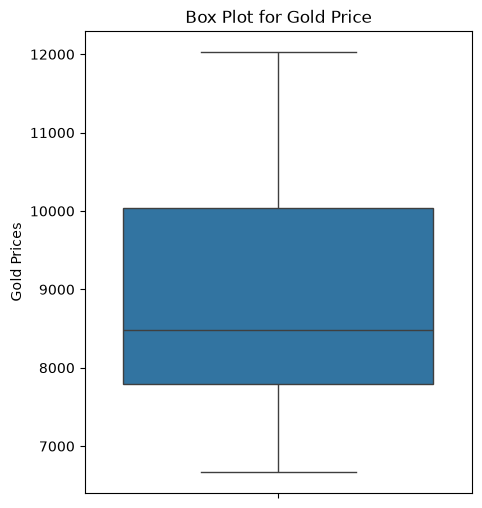

In [29]:
# Identifying the outliers in the Target variable with the box-plot
plt.figure(figsize = (5, 6))
sns.boxplot(goldprice_df['Gold_Price'])
plt.title('Box Plot for Gold Price')
plt.ylabel('Gold Prices')
plt.show()

In [30]:
'''
Interpretation:
-> From the above box plot, we can see that there are no outliers in the Dataset
'''

'\nInterpretation:\n-> From the above box plot, we can see that there are no outliers in the Dataset\n'

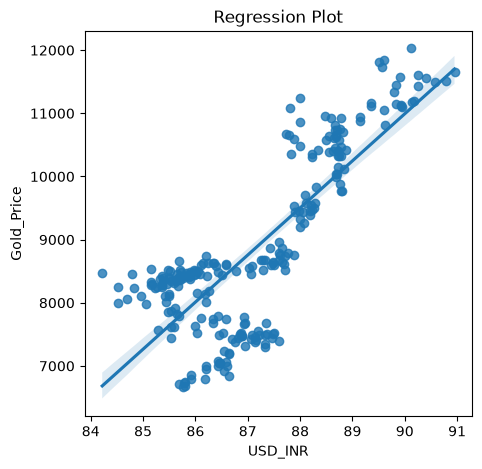

In [31]:
# Regression plot for detecting the linear relationship
plt.figure(figsize = (5, 5))
sns.regplot(x = 'USD_INR', y = 'Gold_Price', data = goldprice_df)
plt.title('Regression Plot')
plt.show()

In [32]:
# Seperating Input (x) & Output Variables (y)
x = goldprice_df['USD_INR'].to_numpy().reshape(-1, 1)
y = goldprice_df['Gold_Price']

In [33]:
# Splitting the data into Training & Testing variables
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, shuffle = False)

In [34]:
# Checking the shape of the train and test variables
x_train.shape, x_test.shape

((200, 1), (50, 1))

In [35]:
# Standardization 
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train) 
x_test_scaled = scaler.transform(x_test)

In [36]:
# Initializing the ML Model
model = LinearRegression()

# Fitting the ML Model
model.fit(x_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[525.4]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,8332
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[14.14]


In [37]:
# Getting the parameters
model.get_params()

{'copy_X': True,
 'fit_intercept': True,
 'n_jobs': None,
 'positive': False,
 'tol': 1e-06}

In [87]:
# Getting the values of 'm' & 'b'
m = model.coef_[0]
b = model.intercept_

print(f'Slope (m)                  =  ₹{m :.2f} per 1 USD/INR increase')
print(f'Intercept (b)              =  ₹{b:.2f}')
print(f'Best Fit Line: Gold_Price (y) =  ({m:.2f} (m) * USD_INR (x)) + ({b:.2f} (c))')

Slope (m)                  =  ₹525.40 per 1 USD/INR increase
Intercept (b)              =  ₹8332.29
Best Fit Line: Gold_Price (y) =  (525.40 (m) * USD_INR (x)) + (8332.29 (c))


In [39]:
'''
m (Slope)           -> ₹525.40 per 1 USD/INR increase
x (Input Variable)  -> USD_INR 
c/b (Intercept)     -> ₹8332.29 
'''

'\nm (Slope)           -> ₹525.40 per 1 USD/INR increase\nx (Input Variable)  -> USD_INR \nc/b (Intercept)     -> ₹8332.29 \n'

In [40]:
# Taking the predictions from the Model
y_train_pred = model.predict(x_train_scaled)
y_pred = model.predict(x_test_scaled)             

In [41]:
y_pred

array([ 8983.88206798,  8926.63916732,  8983.88206798,  8859.85578322,
        8878.9367501 ,  8902.78795871,  9088.82738586,  9093.59762758,
        9150.84052824,  9284.40729645,  9355.96092228,  9327.33947195,
        9332.10971367,  9251.0156044 ,  9303.48826334,  9298.71802162,
        9322.56923023,  9208.0834289 ,  9265.32632956,  9375.04188917,
        9308.25850506,  9289.17753817,  9251.0156044 ,  9217.62391235,
        9313.02874678,  9761.43146863,  9532.45986598,  9532.45986598,
        9632.63494214,  9627.86470042,  9751.89098518,  9899.76847856,
       10019.0245216 ,  9861.60654478,  9909.308962  ,  9999.94355471,
        9899.76847856,  9837.75533617, 10057.18645537, 10214.60443219,
       10310.00926663, 10391.1033759 , 10133.51032292, 10061.9566971 ,
        9732.8100183 ,  9747.12074346,  9704.18856797,  9990.40307127,
        9856.83630306,  9890.22799511])

In [42]:
y_test

206    11246.72
207    10586.97
208    10489.32
209    10667.88
210    10654.22
211    10358.73
212    10312.28
213    10358.18
214    10418.10
215    10402.28
216    10466.17
217    10322.50
218    10408.75
219    10387.17
220    10451.74
221    10743.66
222    10736.54
223    10961.89
224    10931.99
225    10699.48
226    10632.88
227    10609.07
228    10642.40
229    10578.75
230    10656.06
231    10809.37
232    10875.01
233    10943.66
235    11109.80
236    11163.26
237    11056.90
238    11128.13
239    11192.70
240    11154.14
241    11098.63
242    11174.12
243    11120.41
244    11340.87
245    11437.81
246    11496.49
247    11515.97
248    11653.05
249    11563.16
250    11601.22
251    11732.69
252    11838.01
253    11819.53
254    12027.29
255    11450.30
256    11578.53
Name: Gold_Price, dtype: float64

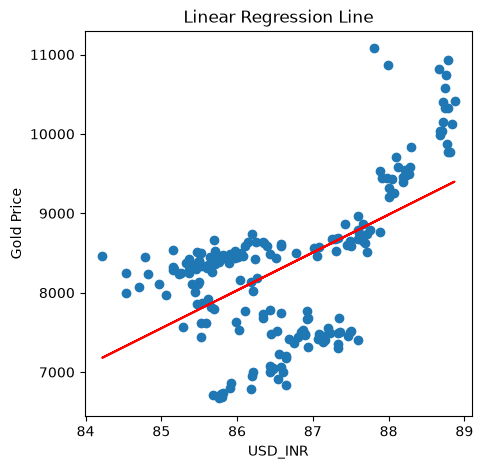

In [43]:
# PLotting the Predictions for analyzation
plt.figure(figsize = (5,5))
plt.scatter(x_train, y_train)
plt.plot(x_train, y_train_pred, color = 'r')
plt.title('Linear Regression Line')
plt.xlabel('USD_INR')
plt.ylabel('Gold Price')
plt.show()

In [44]:
# Model Evaluation for Training Data
print(f'Training RMSE": {np.round(np.sqrt(metrics.mean_squared_error(y_train, y_train_pred)), 3)}')
print(f'Training R2_Score: {np.round(metrics.r2_score(y_train, y_train_pred), 3)}')

Training RMSE": 772.822
Training R2_Score: 0.316


In [45]:
# Model Eavluation for Testing Data
print(f'Testing RMSE: {np.round(np.sqrt(metrics.mean_squared_error(y_test, y_pred)), 3)}')
print(f'Testing  R2_Score: {np.round(metrics.r2_score(y_test, y_pred), 3)}')

Testing RMSE: 1463.139
Testing  R2_Score: -8.69


### Hyper Parameter Optimization

In [61]:
# Importing the required library
from sklearn.model_selection import RandomizedSearchCV
param_space = {
    'copy_X' : [True, False],
    'fit_intercept' : [True, False],
    'n_jobs' : [1, 5, 10, 15, None],
    'positive' : [True, False]
}

In [63]:
# Passing arguments into RandomizedSearchCV for cross validation
search = RandomizedSearchCV(model, param_space, n_iter = 100, cv = 50)

In [64]:
# Passing the trained data into Cross Validation for tuning
search.fit(x_train, y_train) 

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LinearRegression()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'copy_X': [True, False], 'fit_intercept': [True, False], 'n_jobs': [1, 5, ...], 'positive': [True, False]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit

In [66]:
# Getting the best parameters from  the above Cross Validated data
search.best_params_

{'positive': True, 'n_jobs': 1, 'fit_intercept': True, 'copy_X': True}

In [69]:
# Initializing the Model for tuning 
tuned_model = LinearRegression(positive = True, n_jobs = 1, fit_intercept = True, copy_X = True)

# Fitting the Model for tuning
tuned_model.fit(x_train_scaled, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",1
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",True
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[525.4]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,8332
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1


In [92]:
# Getting the values of 'm' & 'b'
m = tuned_model.coef_[0]
c = tuned_model.intercept_

# Printing the values
print(f'Tuned Slope: ₹{m:.2f}')
print(f'Tuned Intercept: {c:.2f}')

Tuned Slope: ₹525.40
Tuned Intercept: 8332.29


In [ ]:
'''
From the above, we see that the values of the parameters before & after tuning were the same. 

m (before tuning) = 525.40 
m (after tuning)  = 525.40
c (before tuning) = 8332.29
c (after tuning)  = 8332.29
'''
# But we have seen how hyper parameter optimization will be done through the above steps

### ML Ops
-> Step 1 : Save the ML Model
-> Step 2 : Build Interface
-> Step 3 : Connect Model & Interface

##### Saving the Model

In [111]:
# Importing the required libraries
import pickle

# Opening the file to dump
with open('GoldPrice_pred.pkl', 'wb') as file:
    pickle.dump(model, file)

In [112]:
# Checking whether the model has been dumped corrrectly
with open('GoldPrice_pred.pkl', 'rb') as file:
    pickled_model = pickle.load(file)

In [113]:
pickled_model.coef_[0]

np.float64(525.4035481793148)

In [114]:
# Saving the scaled data
with open('scaled_data.pkl', 'wb') as file:
    pickle.dump(scaler, file)

##### Building the Interface

In [166]:
# Installing the packages
!pip install gradio

Created dataset file at: .gradio\flagged\dataset1.csv


In [161]:
# Importing the required libraries
import gradio as gr

def goldrate_calc(usd_inr):
    scaled_input = scaler.transform(np.array(usd_inr).reshape(-1, 1))
    return model.predict(scaled_input)[0].round(2)

In [162]:
print(f' Gold price in India : ₹{goldrate_calc(80)}')

 Gold price in India : ₹5167.69


In [167]:
# Gradio Interface
interface = gr.Interface(
    fn = goldrate_calc,
    inputs = ["number"],
    outputs =["number"],
    title = 'Gold Price in India for $: '
)


# Dsplayoing the interface
interface.launch(share = True)

* Running on local URL:  http://127.0.0.1:7863

Could not create share link. Please check your internet connection or our status page: https://status.gradio.app.
